In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as f
import torchvision
import torchvision.transforms as transformers

from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import seaborn as sns

In [5]:
def test_installation():
    print(f'PyTorch Version: {torch.__version__}')
    if torch.cuda.is_available():
        print('CUDA is available. GPU를 사용합니다.')
        print(f'사용 가능한 GPU 개수: {torch.cuda.device_count()}')
        print(f'현재 GPU 이름: {torch.cuda.get_device_name(0)}')
    else:
        print('CUDA를 사용할 수 없습니다. CPU 모드로 실행합니다.')

test_installation()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")

PyTorch Version: 2.11.0+cu128
CUDA is available. GPU를 사용합니다.
사용 가능한 GPU 개수: 1
현재 GPU 이름: NVIDIA GeForce RTX 5060 Laptop GPU
Device: cuda


In [ ]:
# seed 고정 (편한 숫자 아무거나 고르기): 재현성을 위해서 사용

torch.manual_seed(42)
np.random.seed(42)

In [7]:
def perceptron_and(x1, x2):
    w = torch.tensor([0.5, 0.5])
    b = torch.tensor(-0.7)
    x = torch.tensor([x1, x2], dtype = torch.float32)

    output = torch.dot(w, x) + b

    return 1 if output >= 0 else 0

print(perceptron_and(0, 0))
print(perceptron_and(0, 1))
print(perceptron_and(1, 0))
print(perceptron_and(1, 1))

0
0
0
1


In [ ]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # nn.Linear(input, output)
        self.fc1 = nn.Linear(2, 3)
        self.fc2 = nn.Linear(3, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))

        return x

model = SimpleNN()
sample_input = torch.tensor([1.0, 2.0])
output = model(sample_input)
print(output)

tensor([0.6693], grad_fn=<SigmoidBackward0>)


In [9]:
# fully_connected

class SimpleNN_Full(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN_Full, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

model = SimpleNN_Full(input_size = 10, hidden_size = 20, output_size = 1)
print(model)

for param in model.parameters():
    print(param.shape)

SimpleNN_Full(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=20, out_features=1, bias=True)
)
torch.Size([20, 10])
torch.Size([20])
torch.Size([1, 20])
torch.Size([1])


In [10]:
X_train = torch.randn(100, 10)
y_train = torch.randn(100, 1)
dataset = TensorDataset(X_train, y_train)

dataloader = DataLoader(dataset, batch_size = 32, shuffle = True)

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

for epoch in range(10):
    for batch in dataloader:
        inputs, targets = batch
        # 5줄 중요
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets) # 예측, 정답 순으로 들어가기
        loss.backward()
        optimizer.step()
        # 여기까지
    print(epoch + 1, loss.item())

1 0.9306035041809082
2 1.979332447052002
3 0.524667501449585
4 0.9314338564872742
5 2.472566843032837
6 1.977538824081421
7 2.6563892364501953
8 1.100563645362854
9 1.5428667068481445
10 0.08924788981676102


In [ ]:
torch.save(model.state_dict(), "model.pth")
model = SimpleNN_Full(input_size = 10, hidden_size = 20, output_size = 1) # 저장된 모델이랑 파라미터가 같아야함.
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

In [13]:
def check_nan_loss(loss, optimizer):
    if torch.isnan(loss).any():
        print("Loss has a NaN.")

        for param_group in optimizer.param_groups:
            param_group["lr"] *= 0.1

        return True
    return False

sample_loss = torch.tensor(float("nan"))
nan_detected = check_nan_loss(sample_loss, optimizer)
print(nan_detected)

Loss has a NaN.
True


In [14]:
transform = transformers.Compose([
    transformers.RandomHorizontalFlip(),
    transformers.RandomRotation(10),
    transformers.ToTensor()
])

print(transform)

Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
)


In [15]:
# mnist 실습

transform = transformers.Compose([
    transformers.ToTensor(),
    transformers.Normalize((0.1307, ), (0.3081, )) # 평균 0.1307, 표준편차 0.3081
])

train_dataset = torchvision.datasets.MNIST(root = "./data", train = True,
                                           transform = transform, download = True)

test_dataset = torchvision.datasets.MNIST(root = "./data", train = False,
                                            transform = transform, download = True)

100%|██████████| 9.91M/9.91M [00:07<00:00, 1.41MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.54MB/s]


In [16]:
train_loader = DataLoader(dataset = train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(dataset = test_dataset, batch_size = 1000, shuffle = False)

print(len(train_loader))
print(len(test_loader))

938
10


In [21]:
# MLP(Multi Layer Perceptron)

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = f.relu(self.fc1(x))
        x = f.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [24]:
model = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [25]:
for epoch in range(10):
    model.train()

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

    print(epoch + 1, loss.item())

1 0.10110925137996674
2 0.04344889149069786
3 0.012642914429306984
4 0.060257263481616974
5 0.17979127168655396
6 0.01980312541127205
7 0.010176688432693481
8 0.09298141300678253
9 0.0003571010602172464
10 0.0009002903825603426


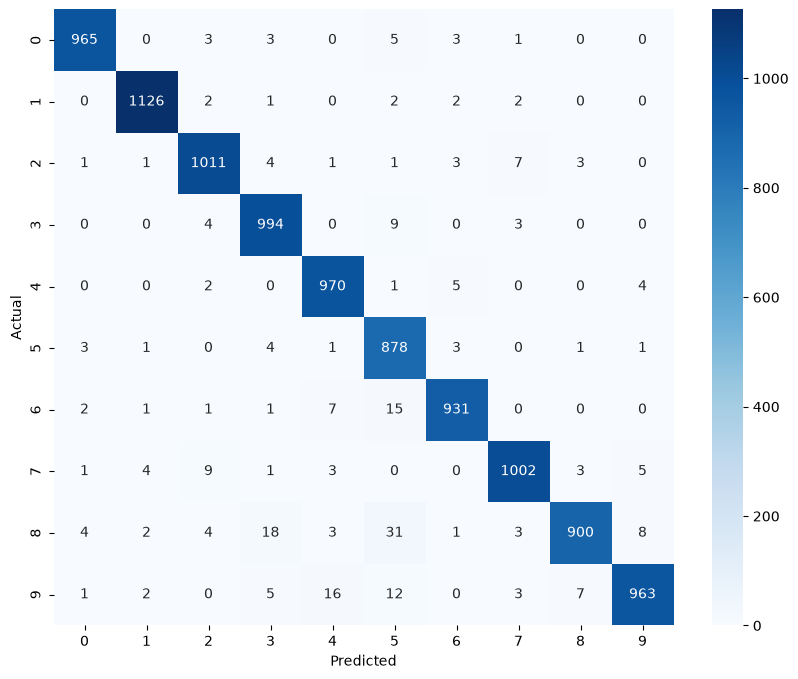

In [26]:
model.eval()
all_targets = []
all_preds = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)

        _, predicted = torch.max(output.data, 1)
        all_targets.extend(target.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

targets = np.array(all_targets)
preds = np.array(all_preds)

cm_mnist = confusion_matrix(targets, preds)
plt.figure(figsize = (10, 8))
sns.heatmap(cm_mnist, annot = True, fmt = "d", cmap = "Blues", xticklabels = range(10), yticklabels = range(10))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

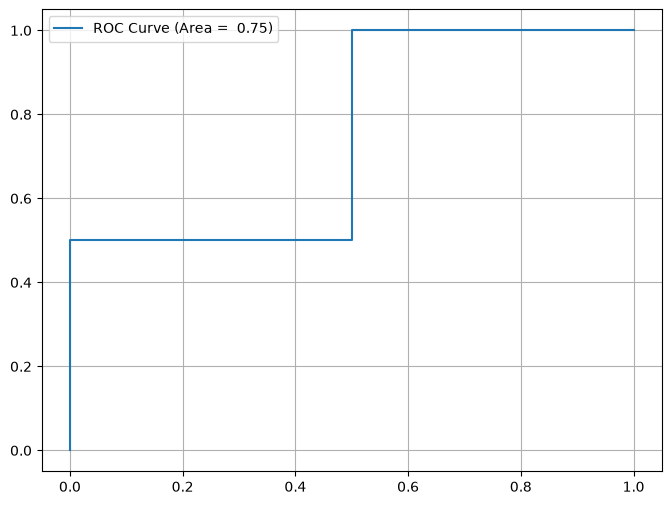

In [28]:
y_scores = np.array([0.1, 0.4, 0.35, 0.8])
y_test = np.array([0, 0, 1, 1])

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (8, 6))
plt.plot(fpr, tpr, label = f"ROC Curve (Area = {roc_auc: .2f})")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
scheduler = ReduceLROnPlateau(optimizer, mode = "min", patience = 3, factor = 0.1)

for epoch in range(50):
    # train_loss가 아니라 val_loss
    # train_one_epoch(model, train_loader, ...)
    # val_loss = evaluate(model, val_loader)
    # scheduler.step(val_loss)
    train_loss = 0.2 * (50 - epoch)
    scheduler.step(train_loss)

In [31]:
# batch normalization

class MLP_NM(nn.Module):
    def __init__(self):
        super(MLP_NM, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = f.relu(self.bn1(self.fc1(x)))
        x = f.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)

In [33]:
# Dropout

class MLP_Drop(nn.Module):
    def __init__(self):
        super(MLP_Drop, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.dropout1 = nn.Dropout(0.50)
        # self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.50)
        #self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = f.relu(self.dropout1(self.fc1(x)))
        x = f.relu(self.dropout2(self.fc2(x)))
        x = self.fc3(x)